In [1]:
import dotenv 
from pathlib import Path
from IPython.display import HTML

from text2graph.eval_dataset.data import squadquestions_from_json
from text2graph.eval_dataset.schema import SQuADStratPipelineQuestion


dotenv.load_dotenv()

True

# load handpicked squad questions

Loaded 106 lines from ../data/20240806_combined_test_triplets.json
Preprocessed to 109 lines



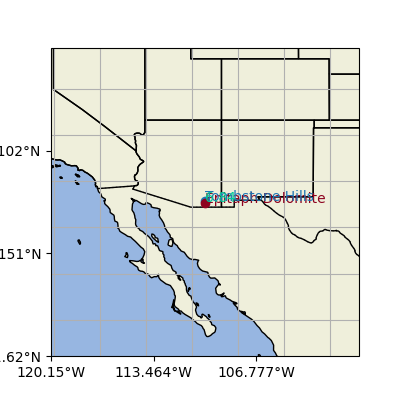

In [2]:
squad_questions_json_path = Path("../data/20240806_combined_test_triplets.json")
squad_questions = squadquestions_from_json(squad_questions_json_path=squad_questions_json_path)
HTML(squad_questions[0].html_format())

In [3]:
from text2graph.eval_dataset.data import label_impossible

labelled_questions = label_impossible(questions=squad_questions)

Impossible: 36, Possible: 73


# query location_stratname API with hand picked squad question context

In [20]:
labelled_questions[90].context

'Colorada heat from ground water. The Candelaria mine (the deepest) is divided with oxide mineralization to the west and sulphide mineralization to the east. The veins in both zones are permeable and allow water flow, in the deeper levels the water in the sulphide areas currently flows into the mine at 44° C and the water in the oxide areas is 36° C.\nThe mine ventilation system is designed to deal with the heat in the mine and the conclusion of the ventilation studies, conducted by a third party consultant, is that refrigeration of the ventilating air will not be required to develop and mine the mineral reserves stated in this technical report (Orellana Wiarco, 2012). However, as mineralization at the La Colorada mine has been shown by diamond drilling information to extend some 425 meters below the deepest level being developed at the time of this report it is possible that refrigeration will be required beyond the mine life presented in this technical report.'

In [22]:
from text2graph.eval_dataset.assessment import query_text_to_graph_api

response = query_text_to_graph_api(labelled_questions[90].context)
response

HTTPError: 422 Client Error: Unprocessable Entity for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph

In [5]:
response

{'triplets': [{'subject': {'name': 'Candelaria mine',
    'lat': 38.1504843,
    'lon': -118.083169,
    'provenance': {'id': '8a2d8349-a91a-48ee-bd66-7c6a87fd79ad',
     'source_name': 'GeocodeAPI',
     'source_url': 'https://geocode.maps.co/search?&q=Candelaria mine',
     'source_version': None,
     'requested': '2024-08-21T15:56:10.167913',
     'additional_values': {},
     'previous': {'id': 'f803591b-3115-4ea6-b42a-619b8b5dc822',
      'source_name': 'OpenSourceModel',
      'source_url': None,
      'source_version': 'mixtral',
      'requested': '2024-06-11T18:15:34.698799Z',
      'additional_values': {'temperature': 0.0, 'prompt': 'v3', 'doc_ids': []},
      'previous': None}}},
   'predicate': 'is divided',
   'object': {'strat_name': 'Candelaria',
    'strat_name_long': 'Candelaria Formation',
    'rank': 'Fm',
    'strat_name_id': 297,
    'concept_id': 12471,
    'bed': '',
    'bed_id': 0,
    'mbr': '',
    'mbr_id': 0,
    'fm': 'Candelaria',
    'fm_id': 297,
    '

# extract subject, predicate, object from response

In [6]:
from text2graph.eval_dataset.assessment import response_subject_predicate_objects

subject_predicate_object_strs = response_subject_predicate_objects(response)
subject_predicate_object_strs


[{'subject': 'Candelaria mine',
  'predicate': 'is divided',
  'object': 'Candelaria'},
 {'subject': 'the deeper levels of the Candelaria mine',
  'predicate': 'flows into',
  'object': 'sulphide areas'},
 {'subject': 'the deeper levels of the Candelaria mine',
  'predicate': 'flows into',
  'object': 'oxide areas'},
 {'subject': 'La Colorada mine',
  'predicate': 'has mineralization that extends',
  'object': 'not specified'}]

# check responses for exact match

In [7]:
from text2graph.eval_dataset.assessment import question_best_exact_match

question_best_exact_match(labelled_questions[90], subject_predicate_object_strs)

0

# get best response f1

In [8]:
from text2graph.eval_dataset.assessment import question_best_mean_f1

question_best_mean_f1(labelled_questions[90], subject_predicate_object_strs)

0

# run on subset of questions

In [14]:
exact_matches = {}
mean_f1s = {}
responses = {}
for i, q in enumerate(labelled_questions):
    try:
        response = query_text_to_graph_api(q.context)
        responses[i] = response
        subject_predicate_object_strs = response_subject_predicate_objects(response)
        exact_matches[i] = question_best_exact_match(q, subject_predicate_object_strs)
        mean_f1s[i] = question_best_mean_f1(q, subject_predicate_object_strs)
    except Exception as e:
        print(f"Error on question {i}: {e}")
        

print(f"Exact Matches: {sum(exact_matches.values())/len(exact_matches.values())}")
print(f"Mean F1: {sum(mean_f1s.values())/len(mean_f1s.values())}")


Error on question5: 500 Server Error: Internal Server Error for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph
Error on question16: 500 Server Error: Internal Server Error for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph
Error on question19: 500 Server Error: Internal Server Error for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph
Error on question21: 500 Server Error: Internal Server Error for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph
Error on question47: 500 Server Error: Internal Server Error for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph
Error on question59: 500 Server Error: Internal Server Error for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph
Error on question60: 500 Server Error: Internal Server Error for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph
Error on question73: 500 Server Error: Internal Server Error for url: http://cosmos0002.chtc.wisc.edu:4510/text_to_graph
Error on question93: 500 Server E

# results per question

In [10]:
for i in exact_matches.keys():
    q = labelled_questions[::10][i]
    print(f"{i}, {q.impossible=}, {exact_matches[i]=}, {mean_f1s[i]=}")



0, q.impossible=False, exact_matches[i]=1, mean_f1s[i]=1.0
1, q.impossible=False, exact_matches[i]=0, mean_f1s[i]=0.4666666666666666
2, q.impossible=False, exact_matches[i]=0, mean_f1s[i]=0.5
3, q.impossible=False, exact_matches[i]=0, mean_f1s[i]=0.6666666666666666
4, q.impossible=False, exact_matches[i]=0, mean_f1s[i]=0.9166666666666666
5, q.impossible=False, exact_matches[i]=0, mean_f1s[i]=0.2222222222222222
6, q.impossible=False, exact_matches[i]=1, mean_f1s[i]=1.0
7, q.impossible=False, exact_matches[i]=0, mean_f1s[i]=0.3333333333333333
8, q.impossible=True, exact_matches[i]=0, mean_f1s[i]=0
9, q.impossible=True, exact_matches[i]=0, mean_f1s[i]=0


# use LLM dynamic prompting 

In [11]:
from text2graph.dynamic_prompt import StratPromptHandlerV4
from text2graph.llm import ask_llm

async def query_with_llm_dynamic_prompting(question: SQuADStratPipelineQuestion):
    ph = StratPromptHandlerV4(model="mixtral")
    triplets_result = await ask_llm(
        text=question.context,
        prompt_handler=ph,
        model='mixtral',
        temperature=0.0,
        to_triplets=True,  # For debugging intermediate steps
        hydrate=False
    )
    return triplets_result


In [15]:
exact_matches_llm_prompting = {}
mean_f1s_llm_prompting = {}
responses_llm_prompting = {}
for i, q in enumerate(labelled_questions):
    try:
        # response = query_text_to_graph_api(q.context)
        response = await query_with_llm_dynamic_prompting(q)
        response = response.model_dump()
        responses_llm_prompting[i] = response
        subject_predicate_object_strs = response_subject_predicate_objects(response)
        exact_matches_llm_prompting[i] = question_best_exact_match(q, subject_predicate_object_strs)
        mean_f1s_llm_prompting[i] = question_best_mean_f1(q, subject_predicate_object_strs)
    except Exception as e:
        print(f"Error on question {i}: {e}")
        

print(f"Exact Matches: {sum(exact_matches_llm_prompting.values())/len(exact_matches_llm_prompting.values())}")
print(f"Mean F1: {sum(mean_f1s_llm_prompting.values())/len(mean_f1s_llm_prompting.values())}")


Error on question 6: 400 Client Error: Bad Request for url: http://cosmos0002.chtc.wisc.edu:11434/api/chat


Error on question 11: 400 Client Error: Bad Request for url: http://cosmos0002.chtc.wisc.edu:11434/api/chat


ERROR:root:ValidationError: when converting {'location': 'Thunder Bay Area, NTS 52A-SW, District of Thunder Bay; Ontario', 'relationship': 'Engineering Geology Terrain Study 71', 'stratigraphic_name': None}
ERROR:root:ValidationError: when converting {'location': 'Vicinity of Port Arthur, District of Thunder Bay', 'relationship': 'Gunflint Iron', 'stratigraphic_name': None}


Error on question 34: 400 Client Error: Bad Request for url: http://cosmos0002.chtc.wisc.edu:11434/api/chat


ERROR:root:ValidationError: when converting {'location': 'Grant Ranges', 'relationship': 'has', 'stratigraphic_name': None}
ERROR:root:ValidationError: when converting {'location': 'Grant Ranges', 'relationship': 'has', 'stratigraphic_name': None}
ERROR:root:ValidationError: when converting {'location': 'Grant Ranges', 'relationship': 'has', 'stratigraphic_name': None}
ERROR:root:ValidationError: when converting {'location': 'TUG deposit', 'relationship': 'contact between', 'stratigraphic_name': ['Missisipian Pilot Shale', 'Devonian Guilmette formation']}
ERROR:root:ValidationError: when converting {'location': 'Gold Hill area', 'relationship': 'general stratigraphy of', 'stratigraphic_name': None}


...

Error on question 93: 400 Client Error: Bad Request for url: http://cosmos0002.chtc.wisc.edu:11434/api/chat


ERROR:root:ValidationError: when converting {'location': 'Tecoma and Lucin Mining Districts', 'relationship': 'sporadic work completed', 'stratigraphic_name': None}
ERROR:root:ValidationError: when converting {'location': 'Jackson mine', 'relationship': 'first large discovery', 'stratigraphic_name': None}
ERROR:root:ValidationError: when converting {'location': 'Jackson mine', 'relationship': 'located approximately four kilometers to the southwest of KB hill', 'stratigraphic_name': None}
ERROR:root:ValidationError: when converting {'location': 'Jackson mine', 'relationship': 'primarily a lead-silver deposit', 'stratigraphic_name': None}
ERROR:root:ValidationError: when converting {'location': 'Jackson mine', 'relationship': 'in production from 1907 to 1955', 'stratigraphic_name': None}
ERROR:root:ValidationError: when converting {'location': 'Jackson mine', 'relationship': '3.12 million lb Pb, 67,274 oz Ag, 21,361 lb Cu, 2000 lb Zn, and 91 oz Au was extracted', 'stratigraphic_name': No

Error on question 97: 400 Client Error: Bad Request for url: http://cosmos0002.chtc.wisc.edu:11434/api/chat
Error on question 101: 400 Client Error: Bad Request for url: http://cosmos0002.chtc.wisc.edu:11434/api/chat
Error on question 105: 400 Client Error: Bad Request for url: http://cosmos0002.chtc.wisc.edu:11434/api/chat


ERROR:root:ValidationError: when converting {'location': 'Blawn Mountain', 'relationship': 'came under control of', 'stratigraphic_name': None}


Exact Matches: 0.13
Mean F1: 0.38891162625100917


In [17]:
sorted([(k, response_subject_predicate_objects(r), mean_f1s_llm_prompting[k]) for k, r in responses_llm_prompting.items()], reverse=True, key=lambda x: x[2])

[(59,
  [{'subject': 'Big Bald Mountain area',
    'predicate': 'hosted in',
    'object': 'shale'},
   {'subject': 'Big Bald Mountain area',
    'predicate': 'hosted in',
    'object': 'limestone'},
   {'subject': 'Big Bald Mountain area',
    'predicate': 'hosted in',
    'object': 'dolomite'},
   {'subject': 'Big Bald Mountain area',
    'predicate': 'hosted in',
    'object': 'intrusive'},
   {'subject': 'Mooney Basin area',
    'predicate': 'hosted in',
    'object': 'Pilot Shale'},
   {'subject': 'Alligator Ridge area',
    'predicate': 'hosted in',
    'object': 'Pilot Shale'},
   {'subject': 'Top deposit (east portion)',
    'predicate': 'contains',
    'object': 'visible gold'}],
  1.0),
 (60,
  [{'subject': 'Big Bald Mountain area',
    'predicate': 'hosted in',
    'object': 'shale'},
   {'subject': 'Big Bald Mountain area',
    'predicate': 'hosted in',
    'object': 'limestone'},
   {'subject': 'Big Bald Mountain area',
    'predicate': 'hosted in',
    'object': 'dolomite